**Alquileres de viviendas en Madrid**

El objetivo principal del proyecto es la construcción de un modelo de predicción de alquileres de viviendas en Madrid, España.

El conjunto de datos contiene 2090 observaciones y 15 características, que se describen a continuación:

*   Id.
*   Distrito.
*   Dirección.
*   Número.
*   Área.
*   Habitaciones.
*   Metros cuadrados.
*   Planta.
*   Exterior.
*   Ascensor.
*   Ático.
*   Casa.
*   Dúplex.
*   Adosado.
*   Alquiler (Variable Objetivo).


Indice de Desarrollo.
1. Importación de librerias.
2. Ingestion de datos.
3. Analisis explorativo.
4. Manipulación de datos.
5. Visualización de datos.
6. Particionamiento de datos.
7. Impact encoding. (Codificación de impacto).
8. Escalamiento standard.
9. Modelo de regresión lineal.

In [3]:
# 1. Importando librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# 2. Ingestión de datos.
# Conexión con drive para obtener el archivo .csv
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Montar origen de datos a dataframe.
df_data = pd.read_excel("/content/drive/MyDrive/TIA_RL_DL_Files/houses_for_rent_madrid.xlsx")

In [5]:
# 3. Analisis exploratorio
# Comprobando formato de tipo para cada variable en dataframe
df_data.dtypes

,0
Id,int64
District,object
Address,object
Number,object
Area,object
Rent,int64
Bedrooms,float64
Sq.Mt,int64
Floor,float64
Outer,float64


In [6]:
# Visualizar los primeros 5 registros del dataframe (conjunto de datos).
df_data.head(5)

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1390,Centro,Ático en calle de Alberto Aguilera,11,Malasaña-Universidad,2490,3.0,97,7.0,1.0,1.0,1,0,0,0
1,1896,San Blás,Piso en calle Luis Sánchez Polack Tip,NaN,Simancas,1300,3.0,110,4.0,1.0,1.0,0,0,0,0
2,1366,Centro,Estudio en Chueca-Justicia,NaN,Chueca-Justicia,800,NaN,33,NaN,NaN,0.0,0,0,0,0
3,1407,Carabanchel,Piso en San Isidro,NaN,San Isidro,600,1.0,45,2.0,1.0,1.0,0,0,0,0
4,1072,Arganzuela,Ático en Acacias,NaN,Acacias,1900,1.0,90,7.0,1.0,1.0,1,0,0,0


In [7]:
# Resumen de estadísticas para explorar y entender los contenidos del dataframe.
df_data.describe(include='all')

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
count,2089.000000,2089,2089,747,2085,2089.000000,2000.000000,2089.000000,1948.000000,1927.000000,1956.000000,2089.000000,2089.000000,2089.000000,2089.000000
unique,NaN,20,1336,137,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Salamanca,Piso en Castellana,1,Recoletos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,313,25,29,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1094.026807,NaN,NaN,NaN,NaN,1932.249402,2.483000,128.919579,25.662731,0.867151,0.880879,0.080900,0.042125,0.030637,0.013404
std,630.612544,NaN,NaN,NaN,NaN,1495.474485,1.305206,115.745014,975.065350,0.339500,0.324013,0.272747,0.200923,0.172373,0.115023
min,1.000000,NaN,NaN,NaN,NaN,450.000000,0.000000,15.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,550.000000,NaN,NaN,NaN,NaN,950.000000,2.000000,65.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1094.000000,NaN,NaN,NaN,NaN,1400.000000,2.000000,90.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1636.000000,NaN,NaN,NaN,NaN,2500.000000,3.000000,147.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
# Validar dimensiones del dataset.
df_data.shape

(2089, 15)

In [9]:
# Comprobando la existencia de valores faltantes.
df_data.isnull().sum()

,0
Id,0
District,0
Address,0
Number,1342
Area,4
Rent,0
Bedrooms,89
Sq.Mt,0
Floor,141
Outer,162


In [ ]:
# 4. Manipulación de datos.
# 4.1 Procederemos a eliminar las columnas redundantes y/o innecesarias para la ejecución del análisis.
df_data1 = df_data.drop(columns=['Id','District','Address','Number'])

In [ ]:
# 4.2 Imputación de valores faltantes con el valor promedio
# Se realiza la sustitución de valores nulos (NaN) por el valor de la medio del conjunto de datos.
df_data1['Floor'].fillna(df_data1['Floor'].mean(), inplace=True)
df_data1['Bedrooms'].fillna(df_data1['Bedrooms'].mean(), inplace=True)
df_data1['Sq.Mt'].fillna(df_data1['Sq.Mt'].mean(), inplace=True)

/tmp/ipython-input-1489700459.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data1['Floor'].fillna(df_data1['Floor'].mean(), inplace=True)
/tmp/ipython-input-1489700459.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
# 4.3 Reemplazando representaciones alternativas con valor NaN.
df_data1.replace(['None','NA','NaN',''], pd.NA, inplace=True)
# Ejecutar el borrado de registros con valores NA
df_data1.dropna(axis=0, inplace=True)
# Validar la existencia de valores NA. Se espera el resultado sea todos los valores 0.
df_data1.isna().sum()

,0
Area,0
Rent,0
Bedrooms,0
Sq.Mt,0
Floor,0
Outer,0
Elevator,0
Penthouse,0
Cottage,0
Duplex,0


In [ ]:
# 4.4 Eliminación de valores atípicos en la variable "Planta"
# Al revisar el archivo excel se identifico la asignación de valores irreales para la variable 'Planta', por lo tanto, se debe depurar estos registros para evitar un impacto negativo en el modelo y este brinde resultados erróneos.
df_data1 = df_data1[df_data1['Floor'] <= 20]

In [ ]:
# Procedemos a eliminar la columna Área por contener data incongruente (texto y números)
df_data2 = df_data1.drop(columns=['Area'])
# Calculamos la matriz de correlación
correlation_matrix = df_data2.corr()
correlation_matrix

,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
Rent,1.000000,0.549526,0.825340,0.146469,0.164670,0.202992,0.130626,0.018640,0.059262,0.016022
Bedrooms,0.549526,1.000000,0.724344,0.052892,0.176442,0.105195,-0.014144,0.067218,0.044700,0.045511
Sq.Mt,0.825340,0.724344,1.000000,0.100254,0.206235,0.183513,0.094109,0.104805,0.121784,0.082272
Floor,0.146469,0.052892,0.100254,1.000000,0.106934,0.215629,0.250732,-0.051749,0.016211,-0.042242
Outer,0.164670,0.176442,0.206235,0.106934,1.000000,0.157876,0.078409,-0.104071,0.019020,-0.084951
Elevator,0.202992,0.105195,0.183513,0.215629,0.157876,1.000000,0.058465,-0.114645,0.027236,-0.093583
Penthouse,0.130626,-0.014144,0.094109,0.250732,0.078409,0.058465,1.000000,-0.012257,-0.057547,-0.010005
Cottage,0.018640,0.067218,0.104805,-0.051749,-0.104071,-0.114645,-0.012257,1.000000,-0.007445,0.816281
Duplex,0.059262,0.044700,0.121784,0.016211,0.019020,0.027236,-0.057547,-0.007445,1.000000,-0.006077
Semidetached,0.016022,0.045511,0.082272,-0.042242,-0.084951,-0.093583,-0.010005,0.816281,-0.006077,1.000000


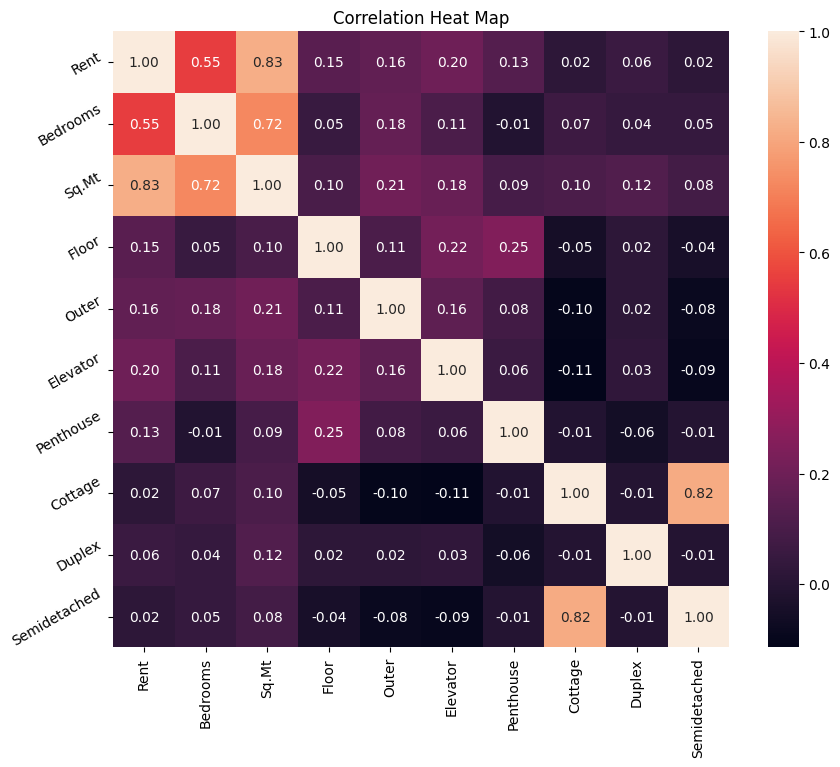

In [ ]:
# 5. Visualización de datos.
# Visualizar el Correlation Heat Map
import seaborn as sns
plt.figure(figsize=(10, 8))
plt.title('Correlation Heat Map')
a = sns.heatmap(correlation_matrix, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

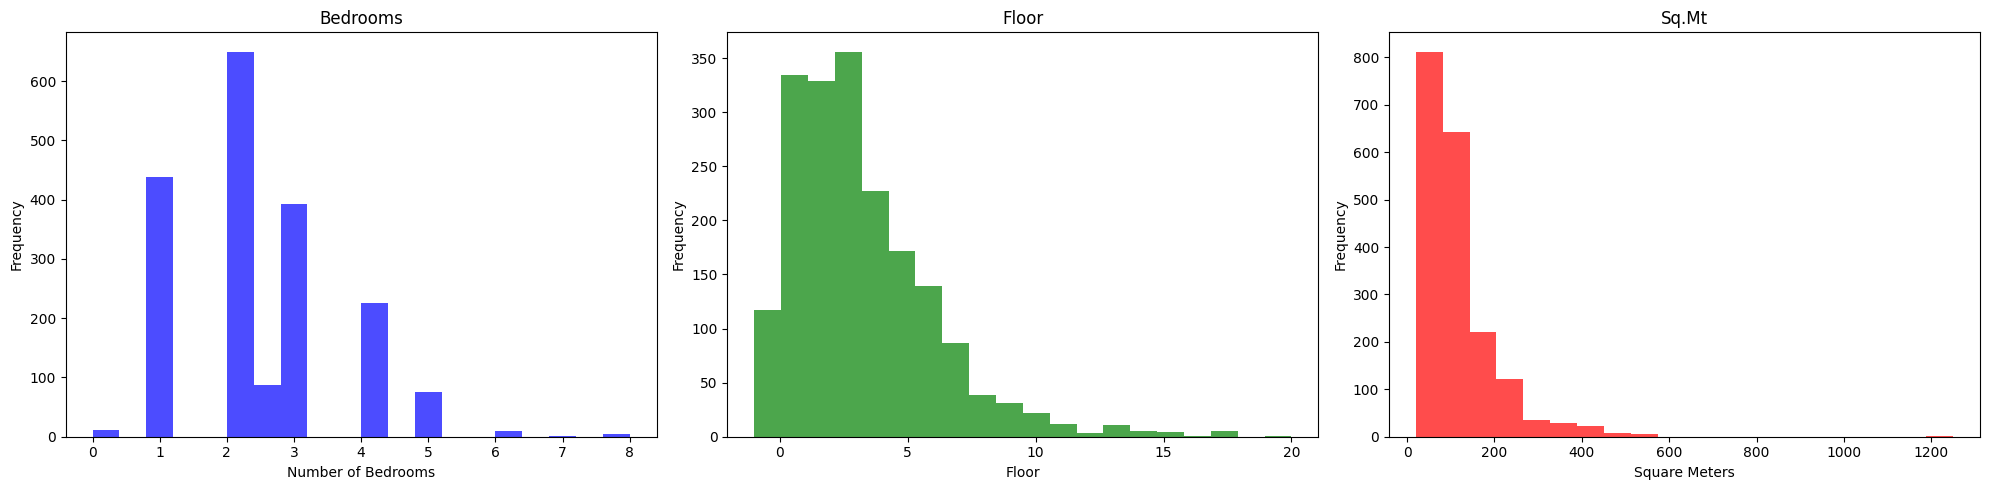

In [ ]:
# 5.2 Graficando histogramas de las variables: Habitaciones, Planta, Metros cuadrados en la misma figura.
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.hist(df_data2['Bedrooms'], bins=20, color='blue', alpha=0.7)
plt.title('Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
plt.hist(df_data2['Floor'], bins=20, color='green', alpha=0.7)
plt.title('Floor')
plt.xlabel('Floor')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(df_data2['Sq.Mt'], bins=20, color='red', alpha=0.7)
plt.title('Sq.Mt')
plt.xlabel('Square Meters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


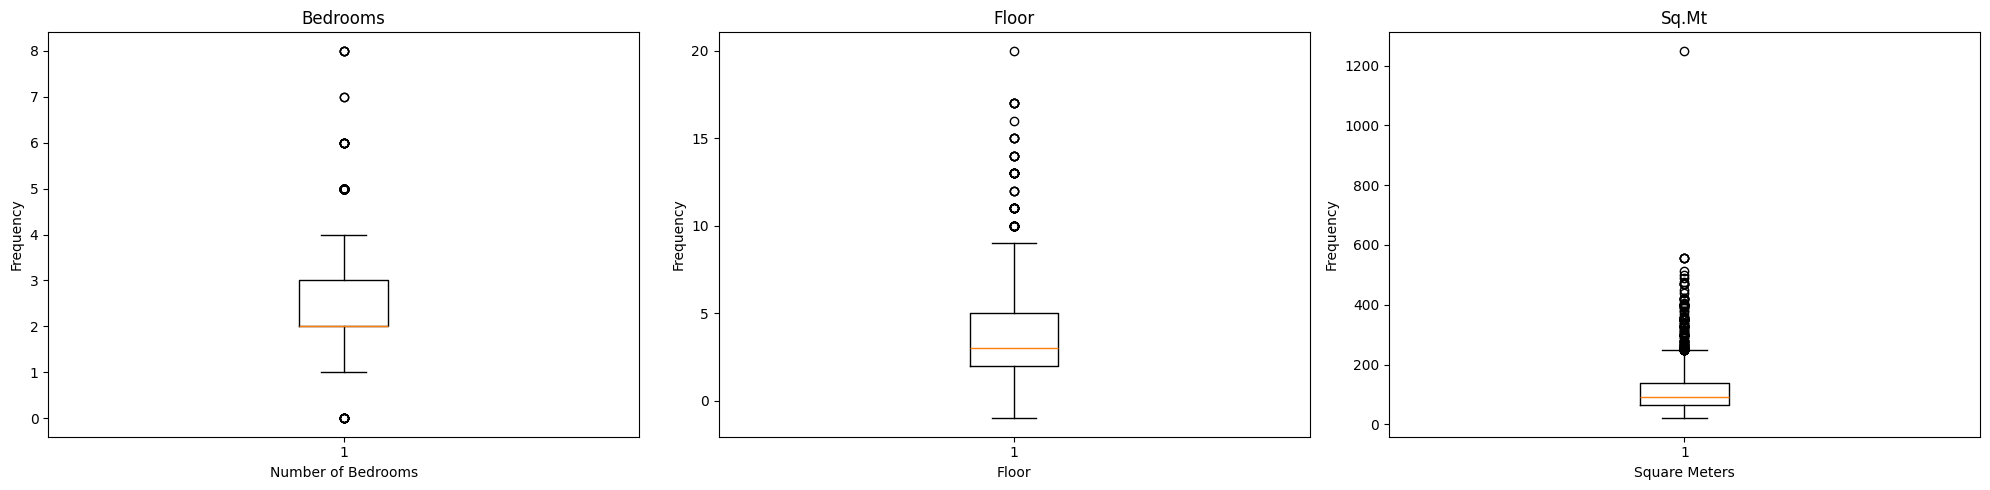

In [ ]:
# 5.3 Boxplots de columnas numéricas.
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.boxplot(df_data2['Bedrooms'])
plt.title('Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
plt.boxplot(df_data2['Floor'])
plt.title('Floor')
plt.xlabel('Floor')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.boxplot(df_data2['Sq.Mt'])
plt.title('Sq.Mt')
plt.xlabel('Square Meters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# 6. Particionamiento de datos.
# Dividir el universo de datos para entrenamiento (70%), Validación (15%), Pruebas (15%)
from sklearn.model_selection import train_test_split
# Primero particionamos 30% para pruebas y el restante 70% es para training.
# Ojo.. debemos usar el df_data1, donde se encuentra la variable 'Area' incluida en las columnas del dataframe.
train, test = train_test_split(df_data1, test_size=0.3, random_state=42)
# Del 30% particionado en el paso anterior, realizamos el particionamiento del 50% para pruebas, por lo tanto, el restante 50% es para validación.
# De esta manera asignamos el 50% de 30% = 15% global para cada set.
test, val = train_test_split(test, test_size=0.5)

In [ ]:
# 7. Realizando el impact encoding para la variable 'Area'.
# La codificación de impacto se realiza únicamente utilizando el conjunto de datos de entrenamiento.
area_means = train.groupby('Area')['Rent'].mean()

# Aplicar el valor de la media del 'Area' a los conjuntos de train, validación y prueba.
for dataset in [train, val, test]:
    dataset['Area_encoded'] = dataset['Area'].map(area_means)

# Si los conjuntos de validación/prueba contienen filas con valores de 'Area' que no fueron observados en el training,
# entonces no se puede calcular la codificación para esas filas y deben ser eliminadas.
for dataset in [train, val, test]:
    dataset.drop(columns=['Area'], inplace=True)
#

In [ ]:
# 8. Escalamiento standard.
# El scaling es una forma de generar características sin unidades que tengan la misma magnitud.
# Utilizar la escala standard (Standard Scaling), el cuál se basa en reemplazar cada valor de una característica
# por su diferencia respecto a la media, medida en unidades de desviación standard.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
train_scaled = pd.DataFrame(train_scaled, columns=train.columns)

In [ ]:
# 9. Regresión Lineal
# Ejecutaremos regresión lineal utilizando solo las características numéricas (incluída la codificación por impacto recién creada ['Area_encoded'])
test.dropna(axis=0, inplace=True)
train.dropna(axis=0, inplace=True)
linearReg = LinearRegression()
linearReg.fit(train[['Bedrooms','Sq.Mt','Floor','Area_encoded']], train['Rent'])
# Calculando Train R^2
trainR2 = linearReg.score(train[['Bedrooms','Sq.Mt','Floor','Area_encoded']], train['Rent'])
# Calculando Test R^2
testR2 = linearReg.score(test[['Bedrooms','Sq.Mt','Floor','Area_encoded']], test['Rent'])
print(f"Train R^2: ", trainR2)
print(f"Test R^2: ", testR2)
#

# Calculando prediccion de Y para training
train['y_predicted'] = linearReg.predict(train[['Bedrooms','Sq.Mt','Floor','Area_encoded']])
# Calculando prediccion de Y para test
test['y_predicted'] = linearReg.predict(test[['Bedrooms','Sq.Mt','Floor','Area_encoded']])
print(f"Train MSE, {mean_squared_error(train['Rent'], train['y_predicted'])}")
print(f"Test MSE, {mean_squared_error(test['Rent'], test['y_predicted'])}")

Train R^2:  0.7735099843965604
Test R^2:  0.8501245464567571
Train MSE, 425139.12196972326
Test MSE, 235514.25026742497


/tmp/ipython-input-772069759.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


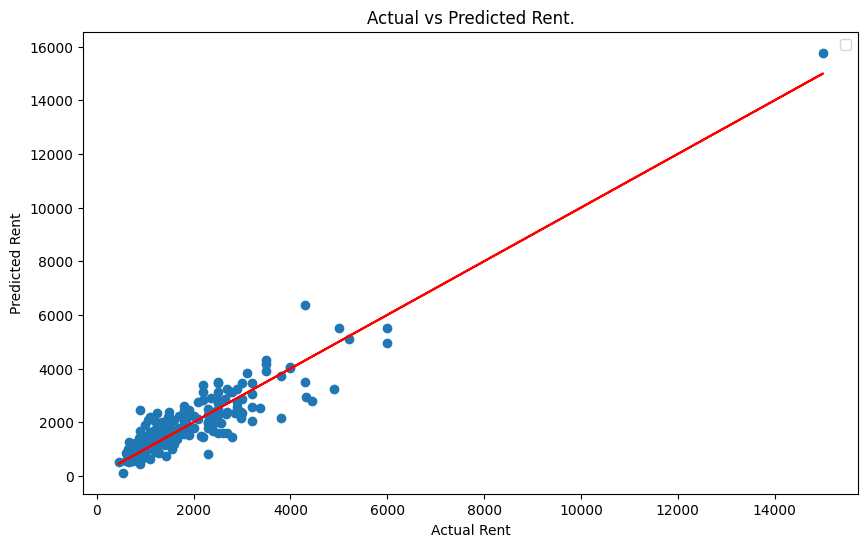

In [ ]:
# 9.2 Plot of the OLS Line
plt.figure(figsize=(10, 6))
plt.scatter(test['Rent'], test['y_predicted'])
plt.plot(test['Rent'], test['Rent'], color='red')
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rent.')
plt.legend()
plt.show()